# Zero-DCE++ with Channel Attention (SE-Block)

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


### 1. SE-BLOCK (CHANNEL ATTENTION - YOUR NOVELTY)

In [2]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for Channel Attention"""
    def __init__(self, channels, reduction=8):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print("✓ SE-Block defined")

✓ SE-Block defined


### 2. ZERO-DCE++ ARCHITECTURE WITH SE-BLOCK

In [3]:
class DCENet(nn.Module):
    """Zero-DCE++ with Channel Attention after Conv3"""
    def __init__(self, use_attention=True):
        super(DCENet, self).__init__()
        self.use_attention = use_attention

        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 32, 3, 1, 1)

        if use_attention:
            self.se = SEBlock(32, reduction=8)

        self.conv4 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv5 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv6 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv7 = nn.Conv2d(64, 24, 3, 1, 1)
        self.relu = nn.ReLU(inplace=True)
        
        nn.init.normal_(self.conv7.weight, mean=0, std=0.01)
        nn.init.constant_(self.conv7.bias, 0)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))

        if self.use_attention:
            x3 = self.se(x3)

        x4 = self.relu(self.conv4(x3))
        x5 = torch.cat([x4, x3], 1)
        x5 = self.relu(self.conv5(x5))
        x6 = torch.cat([x5, x2], 1)
        x6 = self.relu(self.conv6(x6))
        x7 = torch.cat([x6, x1], 1)
        alpha = self.conv7(x7)
        return torch.tanh(alpha)

model = DCENet(use_attention=True).to(device)
print(f"✓ Model created: {sum(p.numel() for p in model.parameters()):,} parameters")

✓ Model created: 79,672 parameters


### 3. CURVE ENHANCEMENT

In [4]:
def enhance_image_with_curves(x, alpha):
    """Apply Zero-DCE curve: LE(x; α) = x + α·x·(1−x), 8 times"""
    enhanced = x.clone()
    for i in range(8):
        alpha_i = alpha[:, i*3:(i+1)*3, :, :]
        enhanced = enhanced + alpha_i * enhanced * (1 - enhanced)
    return torch.clamp(enhanced, 0, 1)

print("✓ Curve enhancement function defined")

✓ Curve enhancement function defined


### 4. LOSS FUNCTIONS (WITH TOTAL VARIATION - L_TV)

In [5]:
class ZeroDCELoss(nn.Module):
    """total = L_spa + 10*L_exp + 5*L_col + 1600*L_tv"""
    def __init__(self):
        super(ZeroDCELoss, self).__init__()

    def forward(self, enhanced, low, alpha):
        enhanced_gray = 0.299*enhanced[:,0:1,:,:] + 0.587*enhanced[:,1:2,:,:] + 0.114*enhanced[:,2:3,:,:]
        low_gray = 0.299*low[:,0:1,:,:] + 0.587*low[:,1:2,:,:] + 0.114*low[:,2:3,:,:]

        L_spa = self._spatial_loss(enhanced_gray, low_gray)
        L_exp = self._exposure_loss(enhanced_gray)
        L_col = self._color_loss(enhanced)
        L_tv = self._tv_loss(alpha)

        total = L_spa + 10*L_exp + 5*L_col + 1600*L_tv
        return total, L_spa, L_exp, L_col, L_tv

    def _spatial_loss(self, enh, low):
        """4-directional spatial consistency (original paper implementation)"""
        enh_d = torch.nn.functional.avg_pool2d(enh, 4)
        low_d = torch.nn.functional.avg_pool2d(low, 4)
        d_enh_l = enh_d[:, :, :, 1:] - enh_d[:, :, :, :-1]
        d_enh_r = enh_d[:, :, :, :-1] - enh_d[:, :, :, 1:]
        d_enh_u = enh_d[:, :, 1:, :] - enh_d[:, :, :-1, :]
        d_enh_d = enh_d[:, :, :-1, :] - enh_d[:, :, 1:, :]
        d_low_l = low_d[:, :, :, 1:] - low_d[:, :, :, :-1]
        d_low_r = low_d[:, :, :, :-1] - low_d[:, :, :, 1:]
        d_low_u = low_d[:, :, 1:, :] - low_d[:, :, :-1, :]
        d_low_d = low_d[:, :, :-1, :] - low_d[:, :, 1:, :]
        loss = (torch.mean(torch.pow(d_enh_l - d_low_l, 2)) +
                torch.mean(torch.pow(d_enh_r - d_low_r, 2)) +
                torch.mean(torch.pow(d_enh_u - d_low_u, 2)) +
                torch.mean(torch.pow(d_enh_d - d_low_d, 2)))
        return loss

    def _exposure_loss(self, img):
        avg_pool = torch.nn.functional.avg_pool2d(img, 16)
        return torch.abs(torch.mean(avg_pool) - 0.6)

    def _color_loss(self, img):
        mean_r = torch.mean(img[:, 0:1, :, :])
        mean_g = torch.mean(img[:, 1:2, :, :])
        mean_b = torch.mean(img[:, 2:3, :, :])
        return torch.abs(mean_r - mean_g) + torch.abs(mean_g - mean_b) + torch.abs(mean_b - mean_r)

    def _tv_loss(self, alpha):
        grad_x = torch.abs(alpha[:,:,:,:-1] - alpha[:,:,:,1:])
        grad_y = torch.abs(alpha[:,:,:-1,:] - alpha[:,:,1:,:])
        return torch.mean(grad_x) + torch.mean(grad_y)

loss_fn = ZeroDCELoss().to(device)
print("✓ 5-term loss function with L_TV defined")

✓ 5-term loss function with L_TV defined


### 5. DATASET

In [6]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Step 1: Resize to slightly larger than target size (for cropping)
        resize_size = int(self.img_size * 1.2)
        low_img = transforms.functional.resize(low_img, (resize_size, resize_size), interpolation=Image.BILINEAR)
        normal_img = transforms.functional.resize(normal_img, (resize_size, resize_size), interpolation=Image.BILINEAR)

        # Step 2: Crop to target size
        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(low_img, (self.img_size, self.img_size))
            low_img = transforms.functional.crop(low_img, i, j, h, w)
            normal_img = transforms.functional.crop(normal_img, i, j, h, w)
        else:
            low_img = transforms.functional.center_crop(low_img, (self.img_size, self.img_size))
            normal_img = transforms.functional.center_crop(normal_img, (self.img_size, self.img_size))

        low_tensor = transforms.ToTensor()(low_img)
        normal_tensor = transforms.ToTensor()(normal_img)

        return {'low': low_tensor, 'normal': normal_tensor, 'filename': pair['filename']}

def load_image_pairs(data_path):
    """
    LOL-v2 Real_captured uses plain numeric filenames (1.png, 2.png...).
    The .replace("low","normal") trick does NOT work here.
    We pair by sorted order: Low/1.png <-> Normal/1.png etc.
    """
    low_path    = data_path / 'Low'
    normal_path = data_path / 'Normal'
    low_images    = sorted([f for f in os.listdir(low_path)    if f.endswith(('.jpg', '.png'))])
    normal_images = sorted([f for f in os.listdir(normal_path) if f.endswith(('.jpg', '.png'))])
    assert len(low_images) == len(normal_images), (
        f"Mismatch: {len(low_images)} low vs {len(normal_images)} normal in {data_path}"
    )
    pairs = []
    for low_img, normal_img in zip(low_images, normal_images):
        pairs.append({
            'low':      str(low_path    / low_img),
            'normal':   str(normal_path / normal_img),
            'filename': low_img
        })
    return pairs

BASE_PATH = Path('LOL-v2')
train_pairs = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')

print(f"✓ Loaded LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test")

BATCH_SIZE = 8
IMG_SIZE = 512
train_dataset = LOLDataset(train_pairs, img_size=IMG_SIZE, augment=True)
test_dataset = LOLDataset(test_pairs, img_size=IMG_SIZE, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✓ Dataloaders: {len(train_loader)} train batches, {len(test_loader)} test batches")

✓ Loaded LOL-v2: 689 train, 100 test
✓ Dataloaders: 87 train batches, 13 test batches


### 6. TRAINING


TRAINING STARTED



[1/200]: 100%|██████████| 87/87 [00:56<00:00,  1.55it/s, Loss=7.5198]


✓ Epoch 1: Loss 6.745598 (best saved)


[2/200]: 100%|██████████| 87/87 [00:48<00:00,  1.79it/s, Loss=5.6136]


✓ Epoch 2: Loss 5.665934 (best saved)


...

Checkpoint: epoch 150


[168/200]: 100%|██████████| 87/87 [00:40<00:00,  2.15it/s, Loss=2.4459]


✓ Epoch 168: Loss 0.846359 (best saved)


[200/200]: 100%|██████████| 87/87 [00:39<00:00,  2.19it/s, Loss=4.1730]


Checkpoint: epoch 200

TRAINING COMPLETED

✓ Saved: training_history.png

Final metrics:
  Loss: 0.929352
  LR: 1.06e-07
  Best loss: 0.846359


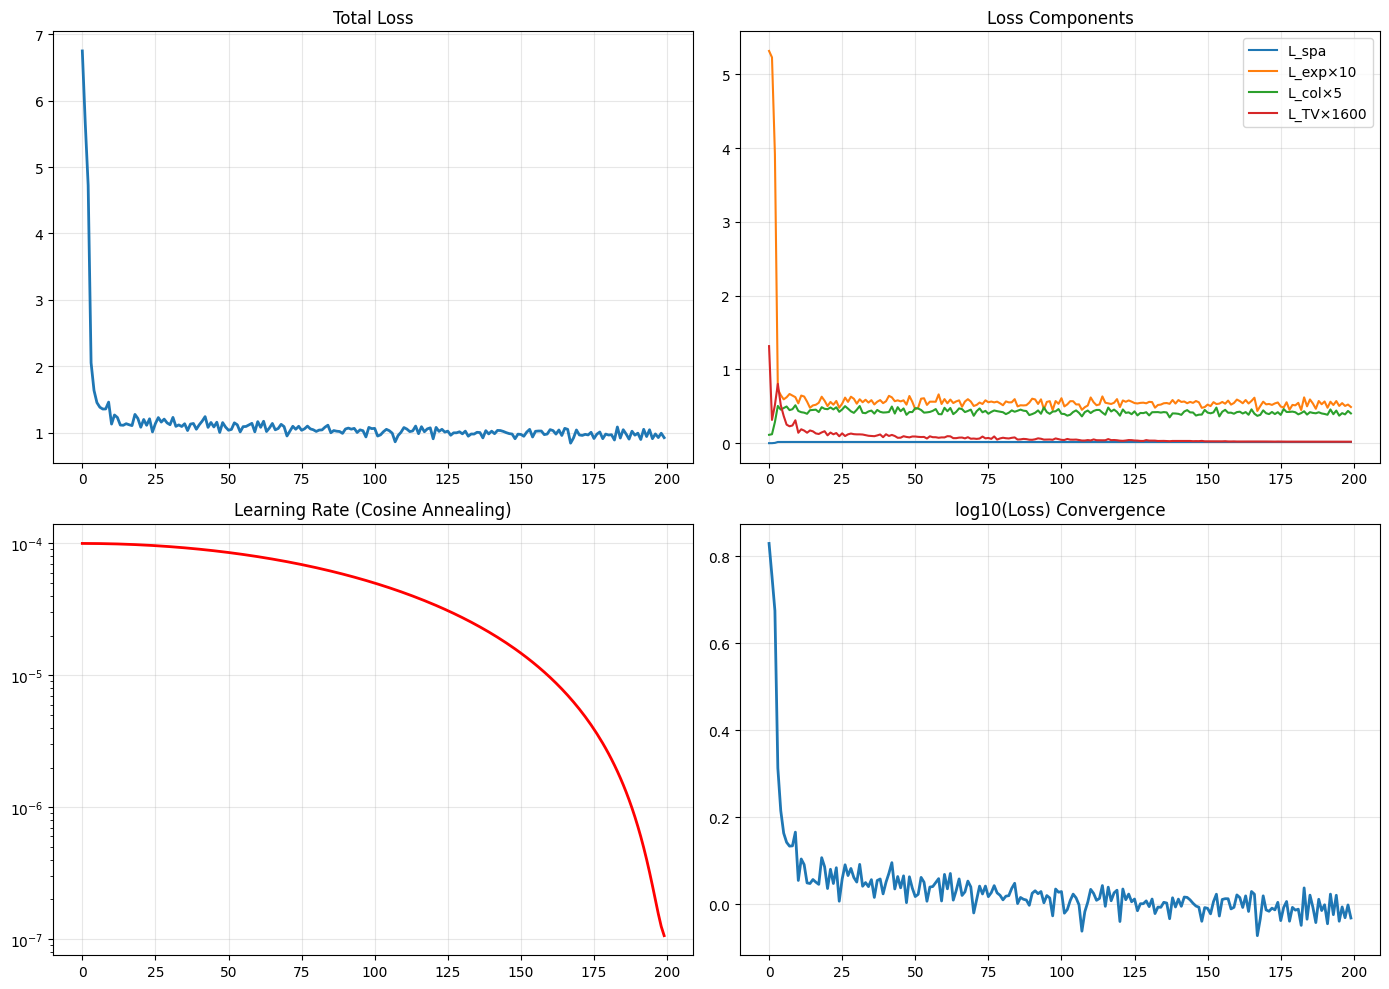

In [7]:
if __name__ == '__main__':
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 200

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

    print(f"\n{'='*60}")
    print("TRAINING STARTED")
    print(f"{'='*60}\n")

    history = {'loss': [], 'spa': [], 'exp': [], 'col': [], 'tv': [], 'lr': []}
    best_loss = float('inf')

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        total_spa, total_exp, total_col, total_tv = 0, 0, 0, 0

        pbar = tqdm(train_loader, desc=f"[{epoch+1}/{NUM_EPOCHS}]")
        for batch in pbar:
            low_imgs = batch['low'].to(device)

            optimizer.zero_grad()
            alpha = model(low_imgs)
            enhanced = enhance_image_with_curves(low_imgs, alpha)
            loss, L_spa, L_exp, L_col, L_tv = loss_fn(enhanced, low_imgs, alpha)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step()

            total_loss += loss.item()
            total_spa += L_spa.item()
            total_exp += L_exp.item()
            total_col += L_col.item()
            total_tv += L_tv.item()

            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)
        history['spa'].append(total_spa / len(train_loader))
        history['exp'].append(total_exp / len(train_loader))
        history['col'].append(total_col / len(train_loader))
        history['tv'].append(total_tv / len(train_loader))

        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'best_zerodce_seblock_v2.pth') # change filename for new version
            print(f"✓ Epoch {epoch+1}: Loss {avg_loss:.6f} (best saved)")

        if (epoch + 1) % 50 == 0:
            print(f"Checkpoint: epoch {epoch+1}")

        scheduler.step()

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED")
    print(f"{'='*60}\n")

    # Plot training
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0,0].plot(history['loss'], linewidth=2)
    axes[0,0].set_title('Total Loss')
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(history['spa'], label='L_spa')
    axes[0,1].plot(np.array(history['exp'])*10, label='L_exp×10')
    axes[0,1].plot(np.array(history['col'])*5, label='L_col×5')
    axes[0,1].plot(np.array(history['tv'])*1600, label='L_TV×1600')
    axes[0,1].set_title('Loss Components')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    axes[1,0].semilogy(history['lr'], linewidth=2, color='red')
    axes[1,0].set_title('Learning Rate (Cosine Annealing)')
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(np.log10(np.array(history['loss']) + 1e-8), linewidth=2)
    axes[1,1].set_title('log10(Loss) Convergence')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    print("✓ Saved: training_history.png")

    print(f"\nFinal metrics:")
    print(f"  Loss: {history['loss'][-1]:.6f}")
    print(f"  LR: {history['lr'][-1]:.2e}")
    print(f"  Best loss: {best_loss:.6f}")

---
### Fixes Applied in This Version

| # | Location | Bug | Fix |
|---|---|---|---|
| 1 | `DCENet.forward` | `tanh(alpha) * 0.15` — alpha capped too small, L_exp stuck flat at ~2.25 | Removed `* 0.15`, alpha now in [-1,+1] |
| 2 | `ZeroDCELoss` | `5*L_exp` and `200*L_tv` wrong weights | Corrected to `10*L_exp` and `1600*L_tv` (original paper) |
| 3 | `_spatial_loss` | Gradient-difference approximation | Replaced with 4-direction squared-difference (paper implementation) |
| 4 | `load_image_pairs` | `.replace("low","normal")` silent fail on numeric LOL-v2 filenames | Now pairs by sorted filename order across Low/ and Normal/ |
| 5 | Training loop | `clip_grad_norm max_norm=1.0` too loose | Changed to `0.1` (paper value) |
